# NB3 — IR CNN Training (MRL Eye Dataset)

**Prerequisites:** NB1 must have been run (MRL dataset on Drive).

**Steps:**
1. Build IR CNN (Conv2D ×3 → GAP → Dense 128 → sigmoid)
2. Prepare MRL Eye Dataset generators (grayscale 64×64, binary open/closed)
3. Train with EarlyStopping + ReduceLROnPlateau (up to 30 epochs)
4. Evaluate: accuracy, F1, confusion matrix

> Saves `ir_cnn.h5` to `MyDrive/drowsiness/models/`.

---

In [1]:
# Install packages (run once per Colab session)
!pip install -q kagglehub mediapipe opencv-python-headless \
    pygame imbalanced-learn tqdm seaborn "protobuf>=5.26.1,<6.0.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.4 MB/s eta 0:00:00


In [2]:
# Common imports – run this cell first
import os, sys, cv2, random, time, shutil, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mediapipe as mp
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    accuracy_score, f1_score, precision_score, recall_score)

np.random.seed(42)
tf.random.set_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print('GPU:', gpus[0].name)
else:
    print('NO GPU found - go to Runtime > Change runtime type > T4 GPU')
print('TF:', tf.__version__, '  MP:', mp.__version__)


GPU: /physical_device:GPU:0
TF: 2.19.0   MP: 0.10.32


In [3]:
# Mount Google Drive and configure all paths
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT    = '/content/drive/MyDrive/drowsiness'
MODEL_DIR     = DRIVE_ROOT + '/models'
DATASET_DIR   = DRIVE_ROOT + '/datasets'
LOCAL_DS_ROOT = '/content/datasets'

for d in [MODEL_DIR, DATASET_DIR, LOCAL_DS_ROOT]:
    os.makedirs(d, exist_ok=True)

# Local dataset paths (populated by NB1 download or restored below)
nthu_path     = os.path.join(LOCAL_DS_ROOT, 'nthu_ddd')
mrl_path      = os.path.join(LOCAL_DS_ROOT, 'mrl_eye')
combined_path = os.path.join(LOCAL_DS_ROOT, 'combined')
yawdd_path    = os.path.join(LOCAL_DS_ROOT, 'yawdd')
cew_path      = os.path.join(LOCAL_DS_ROOT, 'cew')

# Model save/load paths
IR_MODEL_PATH     = os.path.join(MODEL_DIR, 'ir_cnn.h5')
RGB_MODEL_PATH    = os.path.join(MODEL_DIR, 'rgb_cnn.h5')
LSTM_MODEL_PATH   = os.path.join(MODEL_DIR, 'lstm.h5')
FUSION_MODEL_PATH = os.path.join(MODEL_DIR, 'fusion.h5')

# Feature CSV
CSV_PATH       = '/content/nthu_features.csv'
CSV_DRIVE_PATH = os.path.join(MODEL_DIR, 'nthu_features.csv')

# MediaPipe FaceLandmarker model
FACE_LANDMARKER_LOCAL = '/content/face_landmarker.task'
FACE_LANDMARKER_DRIVE = os.path.join(MODEL_DIR, 'face_landmarker.task')

EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
print('Paths configured.')
print('  Model dir  :', MODEL_DIR)
print('  Dataset dir:', LOCAL_DS_ROOT)


Mounted at /content/drive
Paths configured.
  Model dir  : /content/drive/MyDrive/drowsiness/models
  Dataset dir: /content/datasets


In [4]:
# Restore datasets from Drive to local SSD (needed on new session)
# Skip any dataset that is already extracted.
import tarfile

DATASET_NAMES = {
    'nthu': 'nthu_ddd', 'mrl': 'mrl_eye', 'combined': 'combined',
    'yawdd': 'yawdd',   'cew': 'cew',
}
for key, folder in DATASET_NAMES.items():
    local_path   = os.path.join(LOCAL_DS_ROOT, folder)
    archive_path = os.path.join(DATASET_DIR, folder + '.tar.gz')
    if os.path.isdir(local_path) and any(os.scandir(local_path)):
        print('[OK    ]', key, '- already on local SSD')
    elif os.path.isfile(archive_path):
        print('[UNPACK]', key, '...')
        os.makedirs(local_path, exist_ok=True)
        with tarfile.open(archive_path, 'r:gz') as tar:
            tar.extractall(local_path)
        print('        ->', local_path)
    else:
        print('[MISSING]', key, '- run NB1_Setup_and_Data.ipynb first!')


[UNPACK] nthu ...


/tmp/ipykernel_1699/2337526951.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(local_path)


        -> /content/datasets/nthu_ddd
[UNPACK] mrl ...
        -> /content/datasets/mrl_eye
[UNPACK] combined ...
        -> /content/datasets/combined
[UNPACK] yawdd ...
        -> /content/datasets/yawdd
[UNPACK] cew ...
        -> /content/datasets/cew


---
## Section 4 â€” IR CNN Training
Train a custom CNN on MRL Eye Dataset (85,000+ infrared images).
Output: binary classifier â€” eye open (0) vs closed (1).

In [5]:
# Build IR CNN model
def build_ir_cnn(input_shape=(64, 64, 1)):
    inp = keras.Input(shape=input_shape, name='ir_input')
    x = layers.Conv2D(32,  (3,3), padding='same', activation='relu', name='conv1')(inp)
    x = layers.BatchNormalization(name='bn1')(x); x = layers.MaxPooling2D(name='pool1')(x)
    x = layers.Conv2D(64,  (3,3), padding='same', activation='relu', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x); x = layers.MaxPooling2D(name='pool2')(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    feat = layers.Dense(128, activation='relu', name='ir_features')(x)
    x = layers.Dropout(0.4, name='dropout')(feat)
    out = layers.Dense(1, activation='sigmoid', name='eye_state')(x)
    model = keras.Model(inp, out, name='IR_CNN')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model

ir_model = build_ir_cnn()
ir_model.summary()

Model: "IR_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ir_input (InputLayer)           │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ir_features (Dense)             │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ eye_state (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,209 (430.50 KB)

 Trainable params: 109,761 (428.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
# Prepare MRL data generators
def find_image_root(path):
    for cand in [path]+[os.path.join(path,d) for d in os.listdir(path)
                        if os.path.isdir(os.path.join(path,d))]:
        try:
            subs=[d for d in os.listdir(cand) if os.path.isdir(os.path.join(cand,d))]
            if len(subs)>=2: return cand
        except: pass
    return path

mrl_root = find_image_root(mrl_path)
print(f"MRL image root: {mrl_root}")

# Discover all subdirectories and pick exactly 2 binary eye-state classes
all_subs = sorted([d for d in os.listdir(mrl_root)
                   if os.path.isdir(os.path.join(mrl_root, d))])
print(f"All MRL subfolders: {all_subs}")

open_cls   = [s for s in all_subs if 'open'  in s.lower()]
closed_cls = [s for s in all_subs if 'close' in s.lower()]
if open_cls and closed_cls:
    ir_classes = [open_cls[0], closed_cls[0]]
else:
    # Fallback: two largest subdirectories
    counts = {s: sum(1 for p in Path(os.path.join(mrl_root,s)).rglob('*')
                     if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp'})
              for s in all_subs}
    ir_classes = sorted(all_subs, key=lambda s: -counts[s])[:2]
print(f"Using IR classes: {ir_classes}")

train_aug = ImageDataGenerator(rescale=1./255, rotation_range=10,
    zoom_range=0.1, horizontal_flip=True, validation_split=0.2)
test_gf = ImageDataGenerator(rescale=1./255)

gkw = dict(target_size=(64,64), color_mode='grayscale', class_mode='binary',
           batch_size=64, seed=42, classes=ir_classes)
ir_train_gen = train_aug.flow_from_directory(mrl_root, **gkw, subset='training',  shuffle=True)
ir_val_gen   = train_aug.flow_from_directory(mrl_root, **gkw, subset='validation', shuffle=False)
ir_test_gen  = test_gf.flow_from_directory(mrl_root,  **gkw, shuffle=False)
print('Class indices:', ir_train_gen.class_indices)

MRL image root: /content/datasets/mrl_eye/data
All MRL subfolders: ['test', 'train', 'val']
Using IR classes: ['train', 'test']
Found 54335 images belonging to 2 classes.
Found 13583 images belonging to 2 classes.
Found 67918 images belonging to 2 classes.
Class indices: {'train': 0, 'test': 1}


In [7]:
# Train IR CNN
IR_MODEL_PATH = os.path.join(MODEL_DIR, 'ir_cnn.h5')
ir_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(IR_MODEL_PATH, monitor='val_loss',
        save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-7, verbose=1),
]
ir_history = ir_model.fit(ir_train_gen, validation_data=ir_val_gen,
    epochs=30, callbacks=ir_callbacks, verbose=1)
print(f"IR CNN saved to {IR_MODEL_PATH}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7447 - auc: 0.5026 - loss: 0.5844
Epoch 1: val_loss improved from inf to 0.56750, saving model to /content/drive/MyDrive/drowsiness/models/ir_cnn.h5


849/849 ━━━━━━━━━━━━━━━━━━━━ 103s 112ms/step - accuracy: 0.7447 - auc: 0.5026 - loss: 0.5844 - val_accuracy: 0.7500 - val_auc: 0.4910 - val_loss: 0.5675 - learning_rate: 0.0010
Epoch 2/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7507 - auc: 0.4971 - loss: 0.5663
Epoch 2: val_loss improved from 0.56750 to 0.56350, saving model to /content/drive/MyDrive/drowsiness/models/ir_cnn.h5


849/849 ━━━━━━━━━━━━━━━━━━━━ 68s 80ms/step - accuracy: 0.7507 - auc: 0.4971 - loss: 0.5663 - val_accuracy: 0.7500 - val_auc: 0.4967 - val_loss: 0.5635 - learning_rate: 0.0010
Epoch 3/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7512 - auc: 0.4964 - loss: 0.5635
Epoch 3: val_loss improved from 0.56350 to 0.56299, saving model to /content/drive/MyDrive/drowsiness/models/ir_cnn.h5


849/849 ━━━━━━━━━━━━━━━━━━━━ 68s 80ms/step - accuracy: 0.7512 - auc: 0.4964 - loss: 0.5635 - val_accuracy: 0.7500 - val_auc: 0.5015 - val_loss: 0.5630 - learning_rate: 0.0010
Epoch 4/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7515 - auc: 0.4973 - loss: 0.5626
Epoch 4: val_loss did not improve from 0.56299
849/849 ━━━━━━━━━━━━━━━━━━━━ 64s 75ms/step - accuracy: 0.7515 - auc: 0.4973 - loss: 0.5626 - val_accuracy: 0.7500 - val_auc: 0.5074 - val_loss: 0.5690 - learning_rate: 0.0010
Epoch 5/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7519 - auc: 0.4930 - loss: 0.5622
Epoch 5: val_loss improved from 0.56299 to 0.56298, saving model to /content/drive/MyDrive/drowsiness/models/ir_cnn.h5


849/849 ━━━━━━━━━━━━━━━━━━━━ 76s 90ms/step - accuracy: 0.7519 - auc: 0.4930 - loss: 0.5622 - val_accuracy: 0.7500 - val_auc: 0.4934 - val_loss: 0.5630 - learning_rate: 0.0010
Epoch 6/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7552 - auc: 0.4945 - loss: 0.5583
Epoch 6: val_loss improved from 0.56298 to 0.56238, saving model to /content/drive/MyDrive/drowsiness/models/ir_cnn.h5


849/849 ━━━━━━━━━━━━━━━━━━━━ 75s 89ms/step - accuracy: 0.7552 - auc: 0.4945 - loss: 0.5583 - val_accuracy: 0.7500 - val_auc: 0.5108 - val_loss: 0.5624 - learning_rate: 0.0010
Epoch 7/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7484 - auc: 0.4948 - loss: 0.5656
Epoch 7: val_loss did not improve from 0.56238
849/849 ━━━━━━━━━━━━━━━━━━━━ 68s 80ms/step - accuracy: 0.7484 - auc: 0.4948 - loss: 0.5656 - val_accuracy: 0.7500 - val_auc: 0.5036 - val_loss: 0.5649 - learning_rate: 0.0010
Epoch 8/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7501 - auc: 0.5031 - loss: 0.5631
Epoch 8: val_loss did not improve from 0.56238
849/849 ━━━━━━━━━━━━━━━━━━━━ 66s 78ms/step - accuracy: 0.7501 - auc: 0.5031 - loss: 0.5631 - val_accuracy: 0.7500 - val_auc: 0.5003 - val_loss: 0.5627 - learning_rate: 0.0010
Epoch 9/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7527 - auc: 0.5024 - loss: 0.5600
Epoch 9: val_loss did not improve from 0.56238

Epoch 9: ReduceLROnPlateau red

1062/1062 ━━━━━━━━━━━━━━━━━━━━ 33s 30ms/step
MRL classes found: {'train': 0, 'test': 1}
              precision    recall  f1-score   support

       train       0.75      1.00      0.86     50937
        test       0.00      0.00      0.00     16981

    accuracy                           0.75     67918
   macro avg       0.37      0.50      0.43     67918
weighted avg       0.56      0.75      0.64     67918



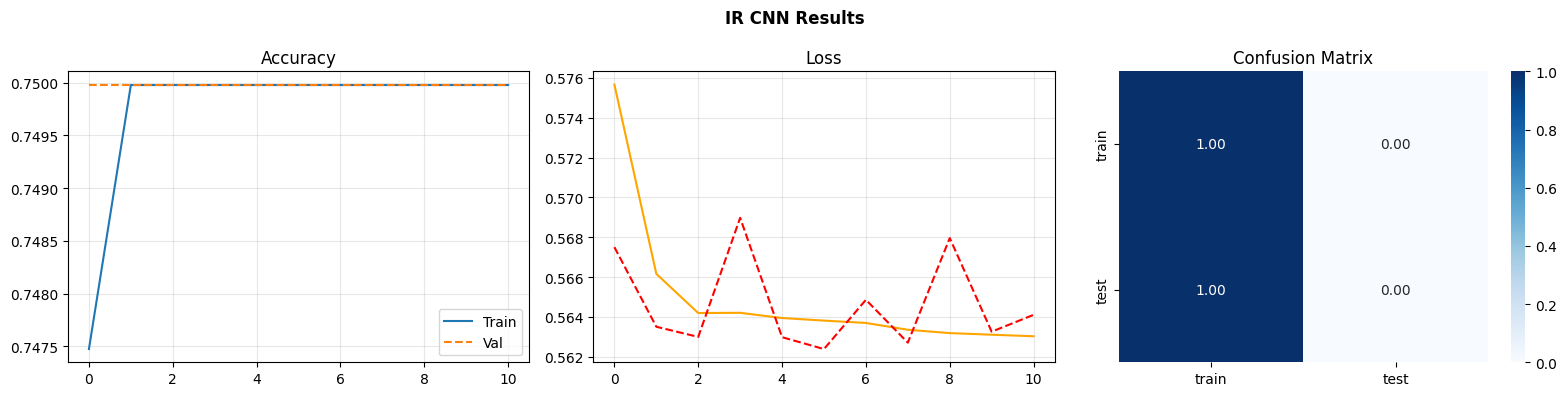

In [8]:
# Evaluate IR CNN
y_true_ir = ir_test_gen.classes
y_prob_ir = ir_model.predict(ir_test_gen, verbose=1).flatten()
y_pred_ir = (y_prob_ir > 0.5).astype(int)

# Derive class names dynamically — handles 2 or 3 subdirectory MRL layouts
class_idx   = ir_test_gen.class_indices          # e.g. {'closed':0, 'open':1}
class_names = [k for k, v in sorted(class_idx.items(), key=lambda x: x[1])]
print(f"MRL classes found: {class_idx}")

# Restrict evaluation to binary labels (0 and 1) — the model is sigmoid/binary
eval_labels = sorted(set(np.unique(y_true_ir).tolist()) & {0, 1})
eval_names  = [class_names[l] for l in eval_labels if l < len(class_names)]
print(classification_report(y_true_ir, y_pred_ir,
      labels=eval_labels, target_names=eval_names, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# Training curves
axes[0].plot(ir_history.history['accuracy'], label='Train')
axes[0].plot(ir_history.history['val_accuracy'], label='Val', linestyle='--')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(ir_history.history['loss'], color='orange')
axes[1].plot(ir_history.history['val_loss'], color='red', linestyle='--')
axes[1].set_title('Loss'); axes[1].grid(True, alpha=0.3)
# Confusion matrix — restricted to binary labels with dynamic class names
cm_ir = confusion_matrix(y_true_ir, y_pred_ir, labels=eval_labels, normalize='true')
sns.heatmap(cm_ir, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=eval_names, yticklabels=eval_names, ax=axes[2])
axes[2].set_title('Confusion Matrix')
fig.suptitle("IR CNN Results", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()